In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

from skimage.feature import hog

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical 


(0.0, 256.0)

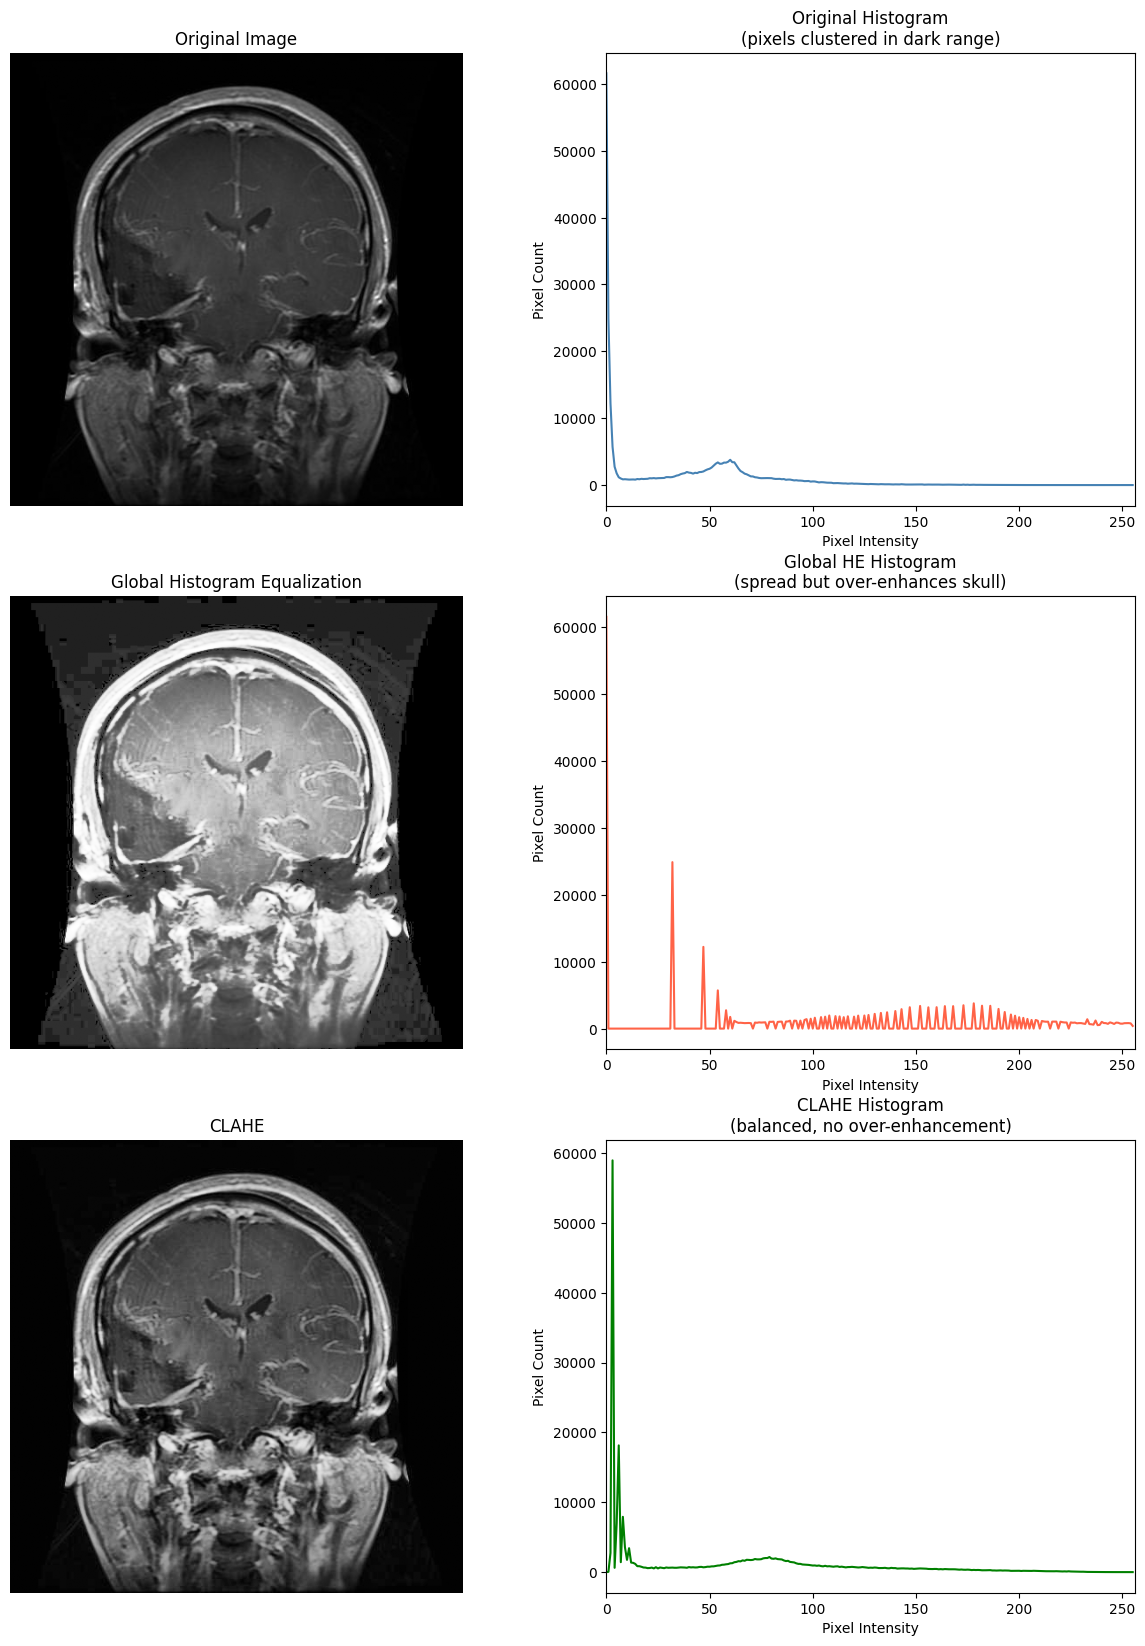

In [3]:
gray = cv2.resize(gray, (512, 512))

#Global Histogram Equalization 
global_eq = cv2.equalizeHist(gray)

#CLAHE 
clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray)

#Compute Histograms 
hist_original = cv2.calcHist([gray],      [0], None, [256], [0, 256])
hist_global   = cv2.calcHist([global_eq], [0], None, [256], [0, 256])
hist_clahe    = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])


fig, axes = plt.subplots(3, 2, figsize=(15, 20))

# Row 1 — Original image & histogram 
axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].plot(hist_original, color='steelblue')
axes[0, 1].set_title('Original Histogram\n(pixels clustered in dark range)')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Pixel Count')
axes[0, 1].set_xlim([0, 256])

# Row 2 output from global histogram equalization &corresponding image 
axes[1, 0].imshow(global_eq, cmap='gray')
axes[1, 0].set_title('Global Histogram Equalization')
axes[1, 0].axis('off')

axes[1, 1].plot(hist_global, color='tomato')
axes[1, 1].set_title('Global HE Histogram\n(spread but over-enhances skull)')
axes[1, 1].set_xlabel('Pixel Intensity')
axes[1, 1].set_ylabel('Pixel Count')
axes[1, 1].set_xlim([0, 256])

# Row 3 CLAHE and coresponding image 
axes[2, 0].imshow(clahe_img, cmap='gray')
axes[2, 0].set_title('CLAHE')
axes[2, 0].axis('off')

axes[2, 1].plot(hist_clahe, color='green')
axes[2, 1].set_title('CLAHE Histogram\n(balanced, no over-enhancement)')
axes[2, 1].set_xlabel('Pixel Intensity')
axes[2, 1].set_ylabel('Pixel Count')
axes[2, 1].set_xlim([0, 256])

In [3]:
data="Training"
image_paths=[]
labels=[]
folders=os.listdir(data)
for folder in folders:
    folder_path=os.path.join(data,folder)
    images=os.listdir(folder_path)
    for image in images:
        image_path=os.path.join(folder_path,image)
        image_paths.append(image_path)
        labels.append(folder)



        

In [4]:
train_df=pd.DataFrame({"image_path":image_paths,"labels":labels})
train_df


,image_path,labels
0,Training\glioma\Tr-glTr_0000.jpg,glioma
1,Training\glioma\Tr-glTr_0001.jpg,glioma
2,Training\glioma\Tr-glTr_0002.jpg,glioma
3,Training\glioma\Tr-glTr_0003.jpg,glioma
4,Training\glioma\Tr-glTr_0004.jpg,glioma
...,...,...
5707,Training\pituitary\Tr-pi_1452.jpg,pituitary
5708,Training\pituitary\Tr-pi_1453.jpg,pituitary
5709,Training\pituitary\Tr-pi_1454.jpg,pituitary
5710,Training\pituitary\Tr-pi_1455.jpg,pituitary


In [5]:
test_data="Testing"
image_paths_test=[]
labels_test=[]
folders=os.listdir(test_data)
for folder in folders:
    folder_path=os.path.join(test_data,folder)
    images=os.listdir(folder_path)
    for image in images:
        image_path=os.path.join(folder_path,image)
        image_paths_test.append(image_path)
        labels_test.append(folder)
        



In [6]:
test_df=pd.DataFrame({"image_path":image_paths_test,"labels":labels_test})
test_df

,image_path,labels
0,Testing\glioma\Te-glTr_0000.jpg,glioma
1,Testing\glioma\Te-glTr_0001.jpg,glioma
2,Testing\glioma\Te-glTr_0002.jpg,glioma
3,Testing\glioma\Te-glTr_0003.jpg,glioma
4,Testing\glioma\Te-glTr_0004.jpg,glioma
...,...,...
1306,Testing\pituitary\Te-pi_0295.jpg,pituitary
1307,Testing\pituitary\Te-pi_0296.jpg,pituitary
1308,Testing\pituitary\Te-pi_0297.jpg,pituitary
1309,Testing\pituitary\Te-pi_0298.jpg,pituitary


In [7]:
valid_df,test_df=train_test_split(test_df,random_state=42,test_size=0.5)




In [ ]:
def preprocess_brain_mri(df):
    images = []
    labels = []
    for i in range(len(df)):
        path = df.iloc[i]['image_path']
        label = df.iloc[i]['labels']       

        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (512, 512))  

        median = cv2.medianBlur(gray, 3)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(median)

        gamma = 0.5
        gamma_corrected = np.power(clahe_img / 255.0, gamma)

        r_min = gamma_corrected.min()
        r_max = gamma_corrected.max()
        stretched = ((gamma_corrected - r_min) / (r_max - r_min)) * 255
        stretched = stretched.astype(np.uint8)

        laplacian = cv2.Laplacian(stretched, cv2.CV_64F)
        laplacian = np.clip(np.abs(laplacian), 0, 255).astype(np.uint8)
        enhanced = cv2.add(stretched, laplacian)


        images.append(enhanced)
        labels.append(label)

    return np.array(images), np.array(labels)

# Apply preprocessing
print("Preprocessing training data...")
train_images, train_labels = preprocess_brain_mri(train_df)
print("Preprocessing validation data...")
valid_images, valid_labels = preprocess_brain_mri(valid_df)
print("Preprocessing test data...")
test_images,  test_labels  = preprocess_brain_mri(test_df)

print(f"Train: {train_images.shape} | Valid: {valid_images.shape} | Test: {test_images.shape}")

Preprocessing training data...
Preprocessing validation data...
Preprocessing test data...
Train: (5712, 512, 512) | Valid: (655, 512, 512) | Test: (656, 512, 512)


In [9]:
def apply_otsu_segmentation(images):
    segmented = []
    for img in images:
        # Otsu threshold → binary mask
        _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological closing to fill holes in the mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Apply mask to keep only brain region
        result = cv2.bitwise_and(img, img, mask=mask)
        segmented.append(result)

    return np.array(segmented)

print("Segmenting training images...")
train_seg = apply_otsu_segmentation(train_images)
print("Segmenting validation images...")
valid_seg = apply_otsu_segmentation(valid_images)
print("Segmenting test images...")
test_seg  = apply_otsu_segmentation(test_images)



Segmenting training images...
Segmenting validation images...
Segmenting test images...


<>:1: SyntaxWarning: invalid escape sequence '\g'
<>:1: SyntaxWarning: invalid escape sequence '\g'
C:\Users\LOQ\AppData\Local\Temp\ipykernel_30752\3778199107.py:1: SyntaxWarning: invalid escape sequence '\g'
  idx = train_df[train_df['image_path'] == "Training\glioma\Tr-gl_0010.jpg"].index[0]


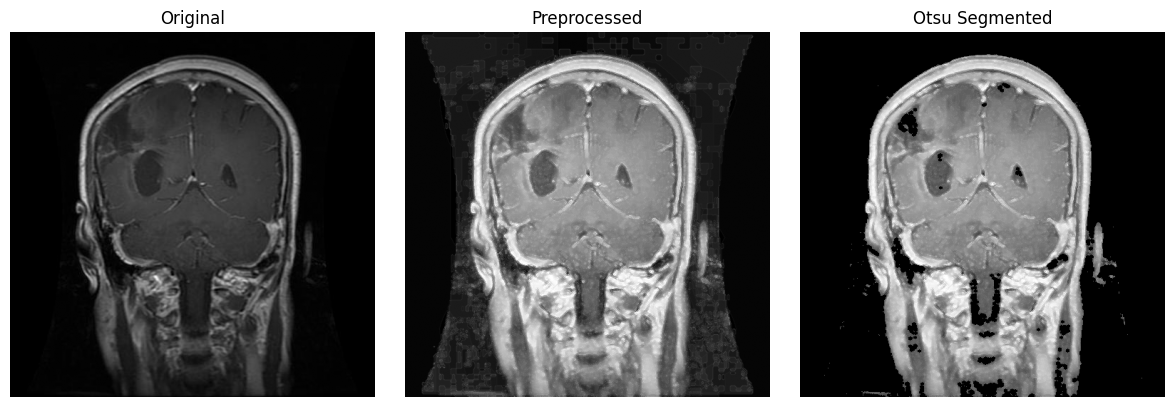

In [10]:

idx = train_df[train_df['image_path'] == "Training\glioma\Tr-gl_0010.jpg"].index[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(cv2.imread(train_df.iloc[idx]['image_path']), cv2.COLOR_BGR2GRAY), cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(train_images[idx], cmap='gray')
axes[1].set_title('Preprocessed')
axes[2].imshow(train_seg[idx], cmap='gray')
axes[2].set_title('Otsu Segmented')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
from skimage.feature import hog

def extract_hog_features(images):
    features = []
    for img in images:
        hog_features = hog(
            img,
            orientations=9,        # number of gradient orientation bins
            pixels_per_cell=(8,8), # size of each cell 8*8 regtangular piece of pixels 
            cells_per_block=(2,2), # block size has 4 cells 
            block_norm='L2-Hys',   # normalization method
            visualize=False
        )
        '''
        ->(512*512)/(8*8)=4096 cells each cell 8*8 so you have 64 cells horizonatal and 64 cells vertical
        ->each cell described by 9 numbers 
        ->each block has 4 cells then each block described by 9*4=36 numbers 
        -> number of blocks horizontal = 64 - 2 + 1=63 #Formula = number of cells - block size + 1
        ->number of blocks vertical = 64 - 2 + 1=63 #Formula = number of cells - block size + 1
        ->total number of blocks = 63*63=3969 blocks
        ->total feature vectore has size= 3969*36=142884 numbers per image 
        '''
        features.append(hog_features)
    return np.array(features)

print("Extracting HOG features...")
X_train = extract_hog_features(train_seg)
X_valid = extract_hog_features(valid_seg)
X_test  = extract_hog_features(test_seg)

print(f"HOG feature vector size : {X_train.shape[1]}")
print(f"Train samples : {X_train.shape[0]}")
print(f"Valid samples : {X_valid.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")

Extracting HOG features...
HOG feature vector size : 142884
Train samples : 5712
Valid samples : 655
Test  samples : 656


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_valid = le.transform(valid_labels)
y_test  = le.transform(test_labels)

print("Classes:", le.classes_)   


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


In [13]:
import gc
del X_train
del X_valid
del X_test

gc.collect()

245

In [14]:
from sklearn.decomposition import PCA
print("Applying PCA (3000 components)...")
pca = PCA(n_components=3000, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)  # learn PCA from training only       # apply same PCA to validation
X_test_pca  = pca.transform(X_test_scaled)        # apply same PCA to test

explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"Variance retained by 3000 components: {explained:.2f}%")
print(f"Feature size reduced: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]}")

Applying PCA (3000 components)...
Variance retained by 3000 components: 88.78%
Feature size reduced: 142884 → 3000


In [15]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Train SVM
print("Training SVM...")
svm1 = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm1.fit(X_train_pca, y_train)
print("Training complete.")

Training SVM...
Training complete.


In [16]:
# Predictions 
y_test_pred  = svm1.predict(X_test_pca)

In [17]:
# Metrics 
def print_metrics(y_true, y_pred, split_name, classes):
    print(f"\n{'='*50}")
    print(f"  {split_name} Results")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print(f"Precision : {precision_score(y_true, y_pred, average='weighted') * 100:.2f}%")
    print(f"Recall    : {recall_score(y_true, y_pred, average='weighted') * 100:.2f}%")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=classes))

print_metrics(y_test,       y_test_pred,  "Test",       le.classes_)


  Test Results
Accuracy  : 95.27%
Precision : 95.25%
Recall    : 95.27%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.92      0.94      0.93       151
  meningioma       0.93      0.88      0.91       164
     notumor       0.98      1.00      0.99       192
   pituitary       0.98      0.98      0.98       149

    accuracy                           0.95       656
   macro avg       0.95      0.95      0.95       656
weighted avg       0.95      0.95      0.95       656



In [14]:
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Train SVM
print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)
print("Training complete.")





Training SVM...
Training complete.


In [15]:
# Predictions 
y_test_pred  = svm.predict(X_test_scaled)

In [16]:
# Metrics 
def print_metrics(y_true, y_pred, split_name, classes):
    print(f"\n{'='*50}")
    print(f"  {split_name} Results")
    print(f"{'='*50}")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print(f"Precision : {precision_score(y_true, y_pred, average='weighted') * 100:.2f}%")
    print(f"Recall    : {recall_score(y_true, y_pred, average='weighted') * 100:.2f}%")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=classes))

print_metrics(y_test,       y_test_pred,  "Test",       le.classes_)


  Test Results
Accuracy  : 87.88%
Precision : 87.91%
Recall    : 87.88%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.87      0.71      0.78       198
  meningioma       0.86      0.84      0.85       186
     notumor       0.85      1.00      0.92       204
   pituitary       0.94      0.95      0.95       212

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.87       800
weighted avg       0.88      0.88      0.88       800

